#Предобработка данных

In [190]:
import pandas as pd

In [191]:
#загрузка данных
df = pd.read_csv('/content/drive/MyDrive/РАБОТА/спутниктест/data.csv')
df.head(10)

,event_category,event_action,event_label,total_events,unique_events
0,city_landing,price_button_submit,Tula / Показать предложения (11),8,7
1,city_landing,price_button_submit,Sochi / Показать предложения (39),12,10
2,city_landing,search-tools-button_open,Penza / Сортировка,2,2
3,city_landing,filters-categories_click,Gelendzhik / ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1
4,city_landing,price_button_submit,Moscow / Показать предложения (345),2,2
5,city_landing,clear_filter_mobile,Vienna,12,11
6,city_landing,start_date_click,Vilnius,9,4
7,city_landing,ticket-type_checkbox,Irkutsk / Мини-группа,29,26
8,city_landing,price_button_submit,Vladivostok / Показать предложения (28),3,3
9,city_landing,filters-categories_click,Krakow / Необычные,3,3


In [192]:
#проверка данных
df.isna().sum()

,0
event_category,0
event_action,0
event_label,0
total_events,0
unique_events,0


In [193]:
# извлечение города из event_label
def extract_city(label):
    parts = label.split('/')
    city = parts[0].strip()
    return city

df['city'] = df['event_label'].apply(extract_city)

In [194]:
import re
# удаление города и очистка event_label
def clean_label(label):
  cleaned = re.sub(r'[\(\)/]', '', label) # убираем скобки и \
  cleaned = re.sub(r'\s+', ' ', cleaned).strip()  # нормализуем пробелы
  return cleaned


df['event_label'] = df['event_label'].apply(clean_label)
df['event_label'] = [label.replace(city, '', 1) for label, city in zip(df['event_label'], df['city'])]

In [195]:
df.head(10)

,event_category,event_action,event_label,total_events,unique_events,city
0,city_landing,price_button_submit,Показать предложения 11,8,7,Tula
1,city_landing,price_button_submit,Показать предложения 39,12,10,Sochi
2,city_landing,search-tools-button_open,Сортировка,2,2,Penza
3,city_landing,filters-categories_click,ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1,Gelendzhik
4,city_landing,price_button_submit,Показать предложения 345,2,2,Moscow
5,city_landing,clear_filter_mobile,,12,11,Vienna
6,city_landing,start_date_click,,9,4,Vilnius
7,city_landing,ticket-type_checkbox,Мини-группа,29,26,Irkutsk
8,city_landing,price_button_submit,Показать предложения 28,3,3,Vladivostok
9,city_landing,filters-categories_click,Необычные,3,3,Krakow


In [196]:
df.isna().sum()

,0
event_category,0
event_action,0
event_label,0
total_events,0
unique_events,0
city,0


In [197]:
# разделение событий

# все события кроме посещения страницы
actions = [
    'search-tools-button_open', 'filters-categories_click', 'price_button_submit', 'ticket-type_checkbox', 'start_date_click',
    'end_date_click', 'price_button_close', 'dates_filter_mobile', 'price_first', 'pay-type_checkbox', 'clear_filter_mobile',
    'price_second', 'price_third'
]

# все фильтры
filter_common = [
    'search-tools-button_open', 'price_button_submit', 'price_button_close', 'clear_filter_mobile', 'dates_filter_mobile',
    'start_date_click', 'end_date_click', 'ticket-type_checkbox', 'pay-type_checkbox'
]

# выбор цены
price_actions = ['price_first', 'price_second', 'price_third']

In [198]:
# разделение на категории
def event_classifier(data):
    action = data['event_action']
    label = data['event_label'].lower()

    # Сначала проверяем наличие признаков сортировки в любом действии
    if 'сортиров' in label:
        # Это может быть как filters-categories_click, так и search-tools-button_open
        return 'sorting'

    # Если не сортировка, то дальше по типам
    if action == 'filters-categories_click':
        return 'category'   # без слова "сортировк" — это категория

    if action in ['search-tools-button_open', 'price_button_submit', 'price_button_close',
                  'clear_filter_mobile', 'dates_filter_mobile', 'start_date_click',
                  'end_date_click', 'ticket-type_checkbox', 'pay-type_checkbox']:
        return 'filters'

    if action in ['price_first', 'price_second', 'price_third']:
        return 'price'

    return 'other'

In [199]:
df['event_type'] = df.apply(event_classifier, axis=1)

In [200]:
df.head()

,event_category,event_action,event_label,total_events,unique_events,city,event_type
0,city_landing,price_button_submit,Показать предложения 11,8,7,Tula,filters
1,city_landing,price_button_submit,Показать предложения 39,12,10,Sochi,filters
2,city_landing,search-tools-button_open,Сортировка,2,2,Penza,sorting
3,city_landing,filters-categories_click,ЭКСКУРСИИ В ГЕЛЕНДЖИКЕ ЦЕНЫ,1,1,Gelendzhik,category
4,city_landing,price_button_submit,Показать предложения 345,2,2,Moscow,filters


In [201]:
df['event_type'].value_counts()

,count
event_type,
filters,14244
category,3352
other,651
sorting,432
price,413


Предобработку данных закончили - переходим к анализу

In [202]:
# общее количество сессий
page_visit = df[df['event_action'] == 'Page Visit'].groupby('city')['unique_events'].sum().reset_index()
page_visit.columns = ['city', 'total_sessions']

# фильтровые события (кроме Page Visit)
filter_df = df[df['event_action'].isin(actions)]

# сумма unique_events по всем фильтровым событиям
filter_sessions = filter_df.groupby('city')['unique_events'].sum().reset_index()
filter_sessions.columns = ['city', 'filter_sessions_estimate']

# объединение
city_stats = page_visit.merge(filter_sessions, on='city', how='left').fillna(0)
city_stats['filter_share'] = city_stats['filter_sessions_estimate'] / city_stats['total_sessions']

city_stats

,city,total_sessions,filter_sessions_estimate,filter_share
0,Aachen,4,0.0,0.000000
1,Abakan,115,36.0,0.313043
2,Abano Terme,7,0.0,0.000000
3,Abkhazia,271,20.0,0.073801
4,Abrau-Durso,4148,225.0,0.054243
...,...,...,...,...
646,sovetsk,20,0.0,0.000000
647,test2,12,0.0,0.000000
648,yantarny,93,24.0,0.258065
649,zaraysk,167,25.0,0.149701


In [203]:
# Для каждого города и каждого event_type считаем сумму unique_events
section_stats = filter_df.groupby(['city', 'event_type'])['unique_events'].sum().unstack(fill_value=0).reset_index()
section_stats = section_stats.merge(page_visit, on='city', how='left')

# использование цены
price_stats = filter_df[filter_df['event_action'].isin(price_actions)].groupby('city')['unique_events'].sum().reset_index()
price_stats.columns = ['city', 'price_sessions_estimate']

# для доп инсайтов
# для filters-categories_click с event_type='category'
categories = df[(df['event_action'] == 'filters-categories_click') & (df['event_type'] == 'category')]
top_categories = categories.groupby('event_label')['unique_events'].sum().sort_values(ascending=False).head(10)

# для сортировок
sortings = df[(df['event_action'] == 'filters-categories_click') & (df['event_type'] == 'sorting')]
top_sortings = sortings.groupby('event_label')['unique_events'].sum().sort_values(ascending=False).head(10)

# для price_button_submit – текст кнопки (часто содержит число предложений)
price_submit = df[df['event_action'] == 'price_button_submit']
price_submit['num_offers'] = price_submit['event_label'].str.extract(r'(\d+)').astype(float)

/tmp/ipykernel_11018/3638593871.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  price_submit['num_offers'] = price_submit['event_label'].str.extract(r'(\d+)').astype(float)


In [204]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')

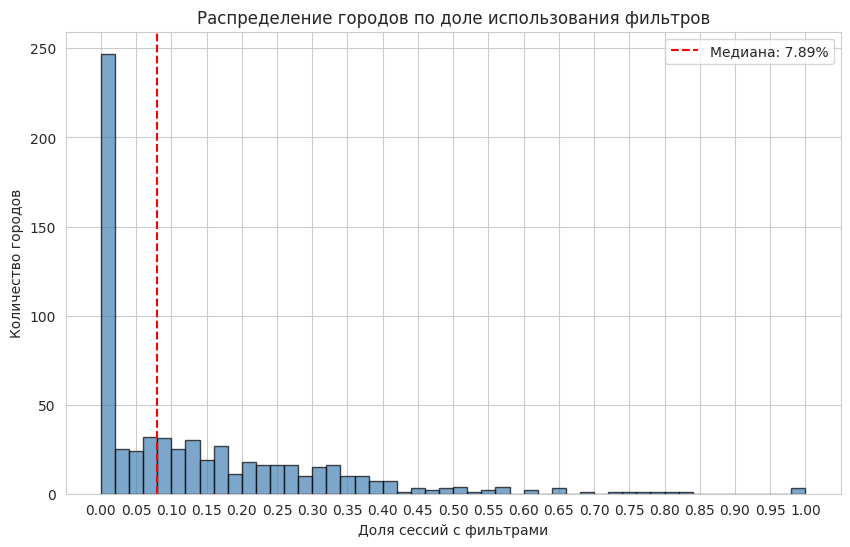

In [205]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(city_stats['filter_share'], bins=50,
                                 edgecolor='black', alpha=0.7, color='steelblue',
                                 range=(0, 1))

plt.xlabel('Доля сессий с фильтрами')
plt.ylabel('Количество городов')
plt.title('Распределение городов по доле использования фильтров')
plt.axvline(city_stats['filter_share'].median(), color='red', linestyle='--',
            label=f'Медиана: {city_stats["filter_share"].median():.2%}')


plt.xticks(np.arange(0, 1.01, 0.05))
plt.legend()
plt.show()

/tmp/ipykernel_11018/3305220352.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top30, x='filter_share', y='city_label', palette='viridis', ax=axes[0],
/tmp/ipykernel_11018/3305220352.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom30, x='filter_share', y='city_label', palette='Reds_r', ax=axes[1],


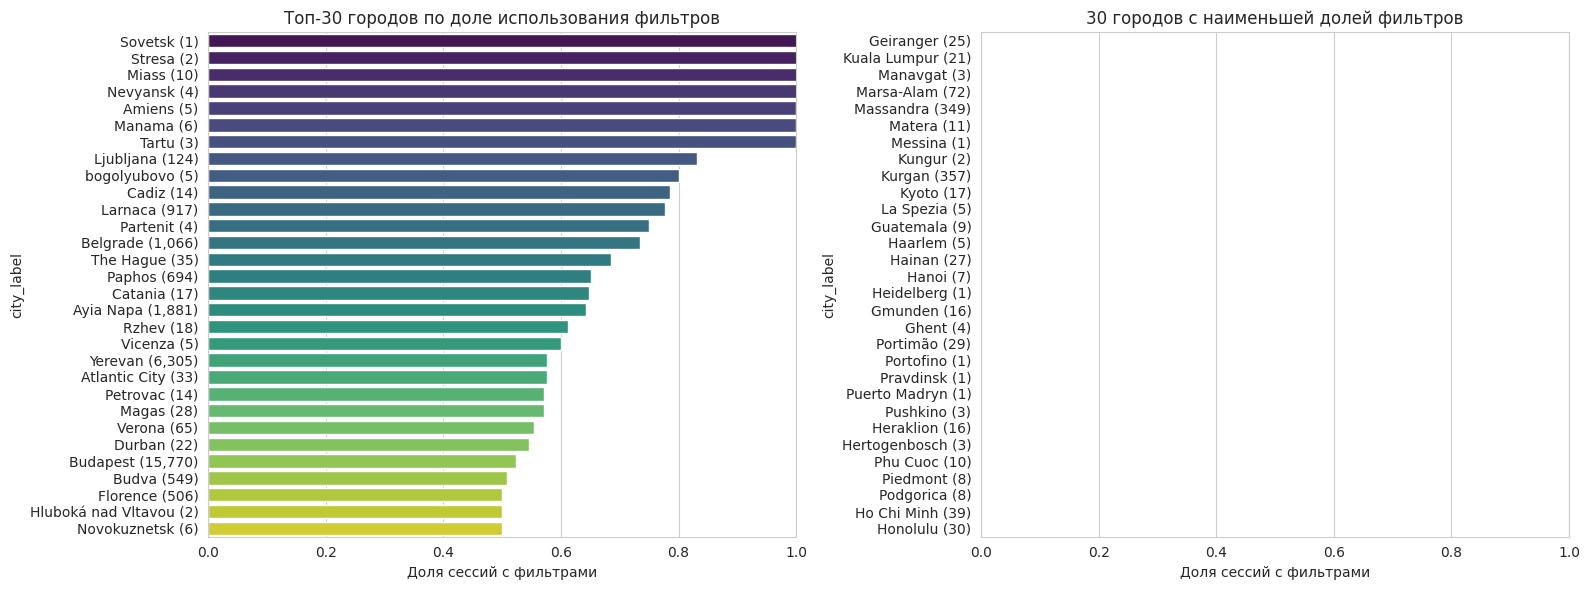

/tmp/ipykernel_11018/3305220352.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom30_positive, x='filter_share', y='city_label', palette='Reds_r',


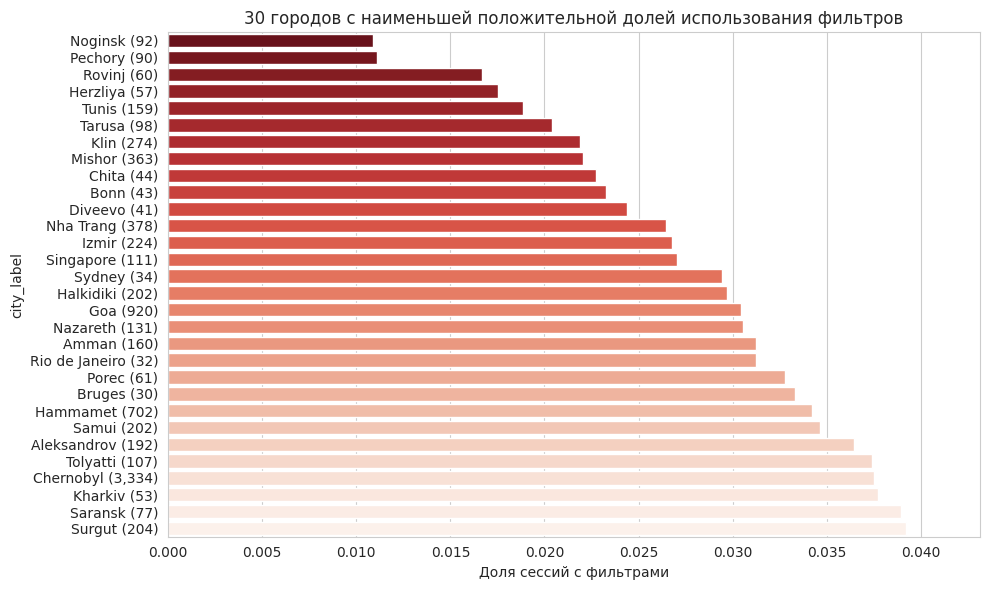

In [206]:
top30 = city_stats.sort_values('filter_share', ascending=False).head(30)
bottom30 = city_stats.sort_values('filter_share', ascending=True).head(30)

top30['city_label'] = top30['city'] + ' (' + top30['total_sessions'].astype(int).apply(lambda x: f'{x:,}') + ')'
bottom30['city_label'] = bottom30['city'] + ' (' + bottom30['total_sessions'].astype(int).apply(lambda x: f'{x:,}') + ')'


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.barplot(data=top30, x='filter_share', y='city_label', palette='viridis', ax=axes[0],
            order=top30['city_label'])
axes[0].set_title('Топ-30 городов по доле использования фильтров')
axes[0].set_xlabel('Доля сессий с фильтрами')
axes[0].set_xlim(0, 1)


sns.barplot(data=bottom30, x='filter_share', y='city_label', palette='Reds_r', ax=axes[1],
            order=bottom30['city_label'])
axes[1].set_title('30 городов с наименьшей долей фильтров')
axes[1].set_xlabel('Доля сессий с фильтрами')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()



city_stats_positive = city_stats[city_stats['filter_share'] > 0]
bottom30_positive = city_stats_positive.sort_values('filter_share', ascending=True).head(30)
bottom30_positive['city_label'] = bottom30_positive['city'] + ' (' + bottom30_positive['total_sessions'].astype(int).apply(lambda x: f'{x:,}') + ')'
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom30_positive, x='filter_share', y='city_label', palette='Reds_r',
            order=bottom30_positive['city_label'])
plt.title('30 городов с наименьшей положительной долей использования фильтров')
plt.xlabel('Доля сессий с фильтрами')
plt.xlim(0, bottom30_positive['filter_share'].max() * 1.1)
plt.tight_layout()
plt.show()

# Поиск лучшего метода ограничения количества сессий


In [207]:
q1 = city_stats['total_sessions'].quantile(0.25)
q2 = city_stats['total_sessions'].quantile(0.50)
q3 = city_stats['total_sessions'].quantile(0.75)

print(f"Распределение числа сессий по городам:")
print(f"  Q1 (25%): {q1:.0f}")
print(f"  Медиана: {q2:.0f}")
print(f"  Q3 (75%): {q3:.0f}")


Распределение числа сессий по городам:
  Q1 (25%): 10
  Медиана: 70
  Q3 (75%): 550


In [208]:
p10 = city_stats['total_sessions'].quantile(0.10)
p5 = city_stats['total_sessions'].quantile(0.05)

print(f"10-й перцентиль: {p10:.0f}")
print(f"5-й перцентиль: {p5:.0f}")


10-й перцентиль: 2
5-й перцентиль: 1


In [209]:
def min_sample_for_proportion(margin_error=0.1, confidence_level=0.95):
    z = 1.96  # для 95% доверительного интервала
    p = 0.5
    n = (z**2 * p * (1-p)) / (margin_error**2)
    return n

min_n = min_sample_for_proportion(margin_error=0.1)
print(f"Минимальное число сессий для погрешности доли ±10%: {min_n:.0f}")

Минимальное число сессий для погрешности доли ±10%: 96


# Ответы на вопросы


## Без фильтрации

In [210]:
# 1. Сколько людей пользуются фильтрами?
total_sessions_all = page_visit['total_sessions'].sum()
total_filter_events = filter_df['unique_events'].sum()  # сумма unique_events по всем фильтровым событиям

min_filter_sessions = city_stats['filter_sessions_estimate'].sum()  # это сумма, а не максимум – это верхняя оценка.


print("\n1. СКОЛЬКО ЛЮДЕЙ ПОЛЬЗУЮТСЯ ФИЛЬТРАМИ?")
print(f"   Общее количество сессий на страницах городов: {total_sessions_all:,}")
print(f"   Суммарное количество уникальных фильтровых событий: {total_filter_events:,}")
print(f"   Доля от всех сессий: {total_filter_events / total_sessions_all:.2%}")


# 2. Города с наибольшей и наименьшей долей использования фильтров
print("2. В КАКИХ ГОРОДАХ ФИЛЬТРАМИ ПОЛЬЗУЮТСЯ БОЛЬШЕ / МЕНЬШЕ?")
top30 = city_stats.sort_values('filter_share', ascending=False).head(30)
bottom30 = city_stats.sort_values('filter_share', ascending=True).head(30)

print("   Топ-30 городов по доле использования фильтров:")
for i, row in top30.iterrows():
    print(f"      {row['city']}: {row['filter_share']:.2%}  (сессий: {int(row['total_sessions']):,})")

print("\n   30 городов с наименьшей долей использования фильтров:")
for i, row in bottom30.iterrows():
    print(f"      {row['city']}: {row['filter_share']:.2%}  (сессий: {int(row['total_sessions']):,})")


# 3. Востребованность разделов фильтров
print("\n3. КАКИЕ РАЗДЕЛЫ ФИЛЬТРОВ НАИБОЛЕЕ ВОСТРЕБОВАНЫ?")
total_by_section = section_stats[['filters', 'sorting', 'category', 'price']].sum().sort_values(ascending=False)
for section, val in total_by_section.items():
    print(f"      {section}: {val:,}")
most_popular = total_by_section.index[0]


# 4. Частота использования выбора цены
print("\n4. КАК ЧАСТО ЛЮДИ ПОЛЬЗУЮТСЯ ВЫБОРОМ ЦЕНЫ?")
total_price_events = price_stats['price_sessions_estimate'].sum() if not price_stats.empty else 0
total_filter_events_all = filter_df['unique_events'].sum()
print(f"   Суммарное количество уникальных событий выбора цены (price_first/second/third): {total_price_events:,}")
print(f"   Доля среди всех фильтровых действий: {total_price_events / total_filter_events_all:.2%}")
print(f"   Доля среди всех сессий (оценка сверху): {total_price_events / total_sessions_all:.2%}")


1. СКОЛЬКО ЛЮДЕЙ ПОЛЬЗУЮТСЯ ФИЛЬТРАМИ?
   Общее количество сессий на страницах городов: 1,384,478
   Суммарное количество уникальных фильтровых событий: 294,969
   Доля от всех сессий: 21.31%
2. В КАКИХ ГОРОДАХ ФИЛЬТРАМИ ПОЛЬЗУЮТСЯ БОЛЬШЕ / МЕНЬШЕ?
   Топ-30 городов по доле использования фильтров:
      Sovetsk: 500.00%  (сессий: 1)
      Stresa: 200.00%  (сессий: 2)
      Miass: 130.00%  (сессий: 10)
      Nevyansk: 125.00%  (сессий: 4)
      Amiens: 100.00%  (сессий: 5)
      Manama: 100.00%  (сессий: 6)
      Tartu: 100.00%  (сессий: 3)
      Ljubljana: 83.06%  (сессий: 124)
      bogolyubovo: 80.00%  (сессий: 5)
      Cadiz: 78.57%  (сессий: 14)
      Larnaca: 77.75%  (сессий: 917)
      Partenit: 75.00%  (сессий: 4)
      Belgrade: 73.36%  (сессий: 1,066)
      The Hague: 68.57%  (сессий: 35)
      Paphos: 65.13%  (сессий: 694)
      Catania: 64.71%  (сессий: 17)
      Ayia Napa: 64.33%  (сессий: 1,881)
      Rzhev: 61.11%  (сессий: 18)
      Vicenza: 60.00%  (сессий: 5)
      Ye

## С фильтрацией по количеству сессий

Исходное количество городов: 651
Городов с сессиями >= 96: 295
Исключено городов (мало сессий): 356


/tmp/ipykernel_11018/1993220445.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top30_filtered, x='filter_share', y='city_label', palette='viridis', ax=axes[0],
/tmp/ipykernel_11018/1993220445.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom30_filtered, x='filter_share', y='city_label', palette='Reds_r', ax=axes[1],


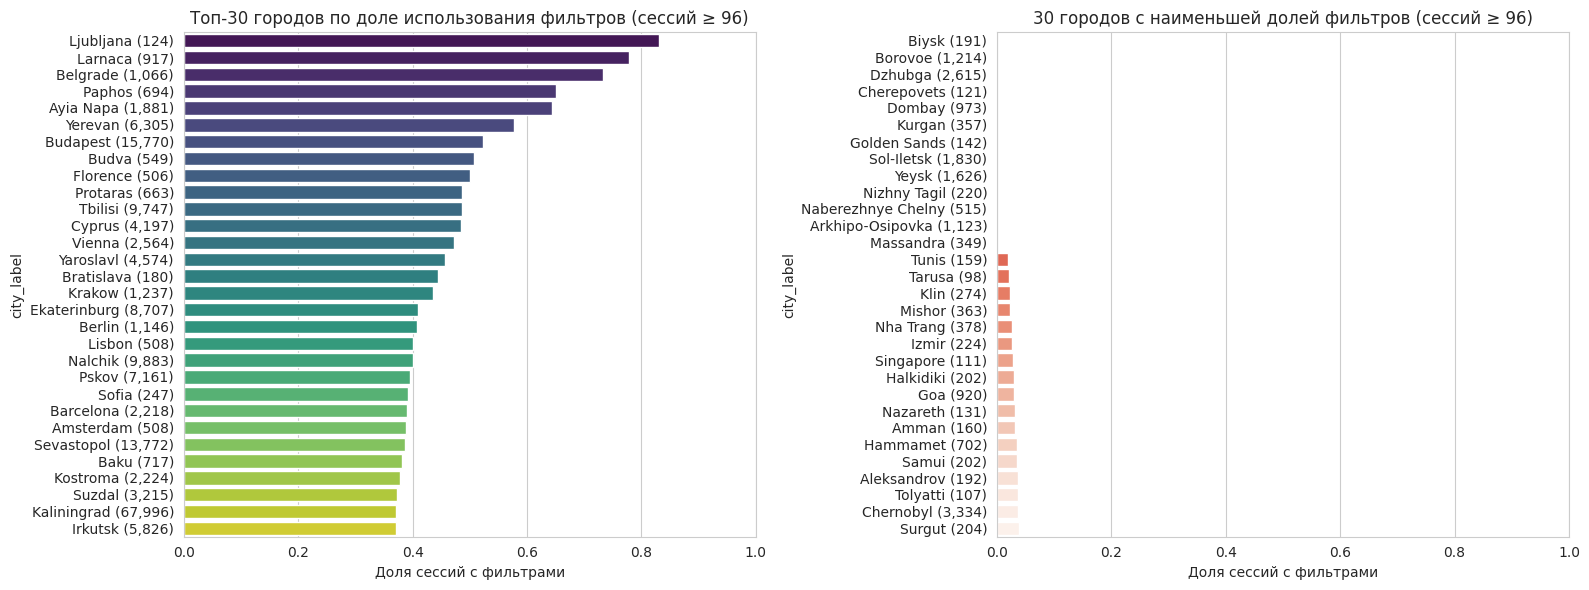

/tmp/ipykernel_11018/1993220445.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom30_positive_filtered, x='filter_share', y='city_label', palette='Reds_r',


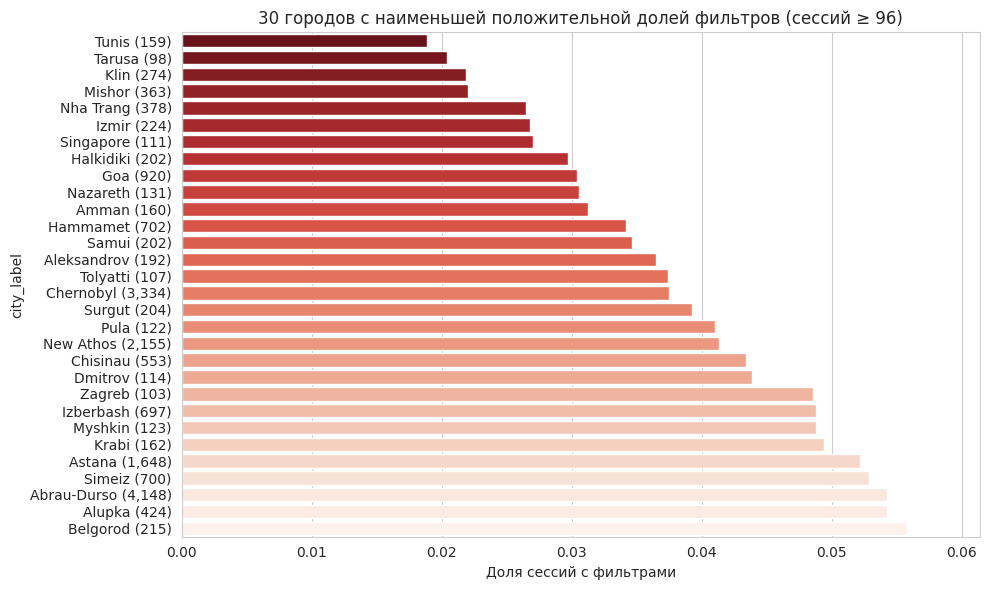

In [211]:
min_sessions = 96

city_stats_filtered = city_stats[city_stats['total_sessions'] >= min_sessions].copy()

print(f"Исходное количество городов: {len(city_stats)}")
print(f"Городов с сессиями >= {min_sessions}: {len(city_stats_filtered)}")
print(f"Исключено городов (мало сессий): {len(city_stats) - len(city_stats_filtered)}")


# Топ-30 городов по доле использования фильтров (с учётом фильтрации)
top30_filtered = city_stats_filtered.sort_values('filter_share', ascending=False).head(30)
bottom30_filtered = city_stats_filtered.sort_values('filter_share', ascending=True).head(30)

top30_filtered['city_label'] = top30_filtered['city'] + ' (' + top30_filtered['total_sessions'].astype(int).apply(lambda x: f'{x:,}') + ')'
bottom30_filtered['city_label'] = bottom30_filtered['city'] + ' (' + bottom30_filtered['total_sessions'].astype(int).apply(lambda x: f'{x:,}') + ')'

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top30_filtered, x='filter_share', y='city_label', palette='viridis', ax=axes[0],
            order=top30_filtered['city_label'])
axes[0].set_title(f'Топ-30 городов по доле использования фильтров (сессий ≥ {min_sessions})')
axes[0].set_xlabel('Доля сессий с фильтрами')
axes[0].set_xlim(0, 1)

sns.barplot(data=bottom30_filtered, x='filter_share', y='city_label', palette='Reds_r', ax=axes[1],
            order=bottom30_filtered['city_label'])
axes[1].set_title(f'30 городов с наименьшей долей фильтров (сессий ≥ {min_sessions})')
axes[1].set_xlabel('Доля сессий с фильтрами')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


# Города с положительной долей (>0) и сессиями >= 96
city_stats_positive_filtered = city_stats_filtered[city_stats_filtered['filter_share'] > 0]
bottom30_positive_filtered = city_stats_positive_filtered.sort_values('filter_share', ascending=True).head(30)
bottom30_positive_filtered['city_label'] = bottom30_positive_filtered['city'] + ' (' + bottom30_positive_filtered['total_sessions'].astype(int).apply(lambda x: f'{x:,}') + ')'

plt.figure(figsize=(10, 6))
sns.barplot(data=bottom30_positive_filtered, x='filter_share', y='city_label', palette='Reds_r',
            order=bottom30_positive_filtered['city_label'])
plt.title(f'30 городов с наименьшей положительной долей фильтров (сессий ≥ {min_sessions})')
plt.xlabel('Доля сессий с фильтрами')
plt.xlim(0, bottom30_positive_filtered['filter_share'].max() * 1.1)
plt.tight_layout()
plt.show()

In [223]:
filtered_cities_list = city_stats_filtered['city'].tolist()
total_sessions_filtered = city_stats_filtered['total_sessions'].sum()
df_filtered = df[df['city'].isin(filtered_cities_list)]
filter_df_filtered = df_filtered[df_filtered['event_action'].isin(actions)]
total_filter_events_filtered = filter_df_filtered['unique_events'].sum()

# 2. Города с наибольшей и наименьшей долей (текстовые топ-30)
print("2. В КАКИХ ГОРОДАХ ФИЛЬТРАМИ ПОЛЬЗУЮТСЯ БОЛЬШЕ / МЕНЬШЕ?")
top30_filtered = city_stats_filtered.sort_values('filter_share', ascending=False).head(30)
bottom30_filtered = city_stats_filtered.sort_values('filter_share', ascending=True).head(30)

print("   Топ-30 городов по доле использования фильтров (сессий ≥ {}):".format(min_sessions))
for _, row in top30_filtered.iterrows():
    print(f"      {row['city']}: {row['filter_share']:.2%}  (сессий: {int(row['total_sessions']):,})")

print("\n  30 городов с наименьшей долей использования фильтров (сессий ≥ {}):".format(min_sessions))
for _, row in bottom30_filtered.iterrows():
    print(f"      {row['city']}: {row['filter_share']:.2%}  (сессий: {int(row['total_sessions']):,})")


# количество городов с нулевым использованием фильтров после фильтрации
zero_filter_after = city_stats_filtered[city_stats_filtered['filter_sessions_estimate'] == 0]
print('\n Количество городов с нулевой долей фильтрации:', len(zero_filter_after))

2. В КАКИХ ГОРОДАХ ФИЛЬТРАМИ ПОЛЬЗУЮТСЯ БОЛЬШЕ / МЕНЬШЕ?
   Топ-30 городов по доле использования фильтров (сессий ≥ 96):
      Ljubljana: 83.06%  (сессий: 124)
      Larnaca: 77.75%  (сессий: 917)
      Belgrade: 73.36%  (сессий: 1,066)
      Paphos: 65.13%  (сессий: 694)
      Ayia Napa: 64.33%  (сессий: 1,881)
      Yerevan: 57.67%  (сессий: 6,305)
      Budapest: 52.38%  (сессий: 15,770)
      Budva: 50.82%  (сессий: 549)
      Florence: 50.00%  (сессий: 506)
      Protaras: 48.57%  (сессий: 663)
      Tbilisi: 48.56%  (сессий: 9,747)
      Cyprus: 48.42%  (сессий: 4,197)
      Vienna: 47.23%  (сессий: 2,564)
      Yaroslavl: 45.61%  (сессий: 4,574)
      Bratislava: 44.44%  (сессий: 180)
      Krakow: 43.65%  (сессий: 1,237)
      Ekaterinburg: 40.99%  (сессий: 8,707)
      Berlin: 40.75%  (сессий: 1,146)
      Lisbon: 40.16%  (сессий: 508)
      Nalchik: 40.13%  (сессий: 9,883)
      Pskov: 39.46%  (сессий: 7,161)
      Sofia: 39.27%  (сессий: 247)
      Barcelona: 39.09%  (сессий